## Final Project

In [52]:
import numpy as np
import matplotlib.pyplot as plt 
from astropy.io import fits 
import sep
import matplotlib.pyplot as plt
from matplotlib import rcParams

from matplotlib.patches import Ellipse
%matplotlib inline
rcParams['figure.figsize'] = [10.,8.]

In [53]:
filename = '/Users/sofia/Downloads/hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits'

In [54]:
data = fits.getdata(filename)

0.0
0.0005398219218477607


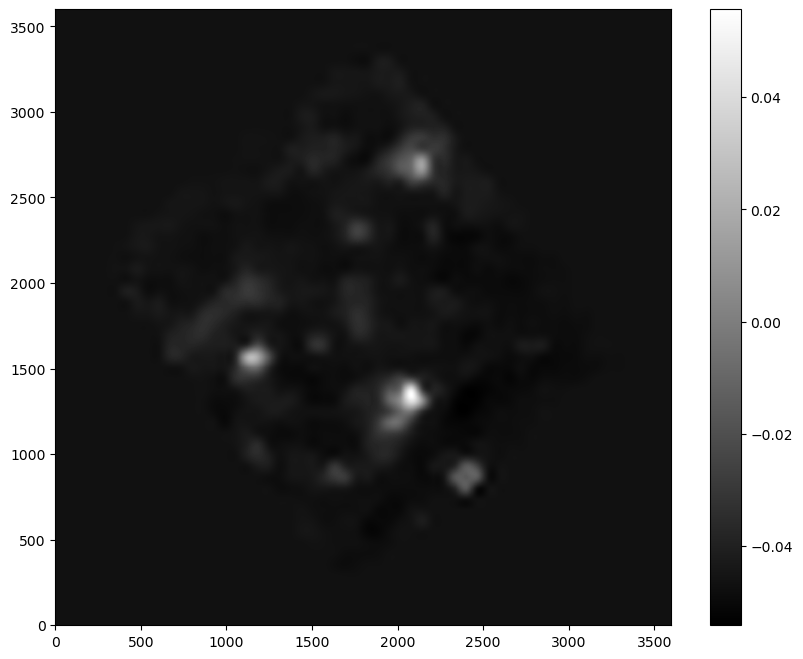

In [55]:
m, s = np.mean(data), np.std(data) 

plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()
data = data.astype(data.dtype.newbyteorder('='))
bkg = sep.Background(data)
print(bkg.globalback)
print(bkg.globalrms)
bkg_image = bkg.back()
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower') 
data_sub = data - bkg

In [56]:
objects = sep.extract(data_sub, 15, err=bkg.globalrms)
len(objects)

1158

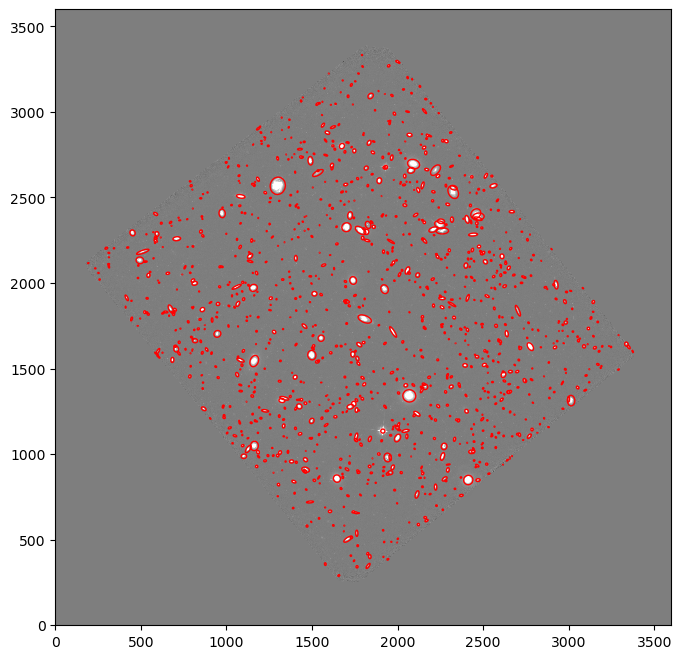

In [57]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

In [58]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'], 
                                    3.0, err=bkg.globalrms, gain=1.0)

In [61]:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i])) 

object 0: flux = 1.153159 +/- 1.073856
object 1: flux = 0.553503 +/- 0.743983
object 2: flux = 1.125336 +/- 1.060822
object 3: flux = 0.874867 +/- 0.935348
object 4: flux = 0.289051 +/- 0.537642
object 5: flux = 0.693598 +/- 0.832830
object 6: flux = 0.214496 +/- 0.463146
object 7: flux = 0.497867 +/- 0.705602
object 8: flux = 0.748867 +/- 0.865376
object 9: flux = 1.255536 +/- 1.120511


std of flux:  25.078515102927742
mean of flux:  2.4864174349629655
Number of objects:  1158


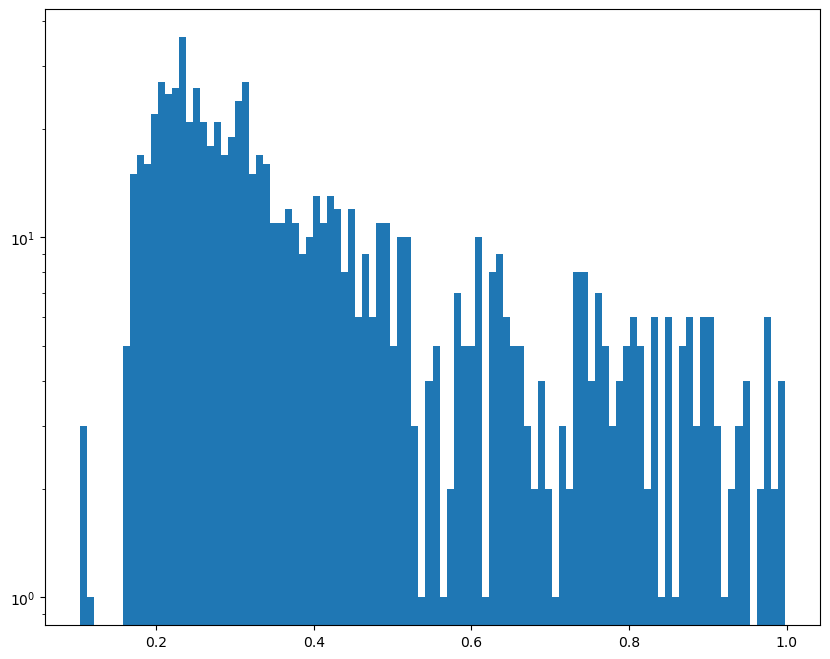

In [60]:
std_of_flux = np.std(flux)
mean_of_flux = np.mean(flux)

n_flux = [] 
for i in flux: 
    if 0 < i < 1: 
        n_flux.append(i)
n_flux = np.array(n_flux)
plt.hist(n_flux, bins=100)
plt.yscale("log")

print("std of flux: ", std_of_flux)
print("mean of flux: ", mean_of_flux)
print("Number of objects: ", len(flux))